In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

soil_path = "../data/raw/state_soil_data.csv"
weather_path = "../data/raw/state_weather_data_1997_2020.csv"

soil = pd.read_csv(soil_path)
weather = pd.read_csv(weather_path)

print("Soil shape:", soil.shape)
print("Weather shape:", weather.shape)
soil.head(), weather.head()

Soil shape: (30, 5)
Weather shape: (720, 5)


(               state   N   P   K   pH
 0     Andhra Pradesh  78  45  22  6.8
 1  Arunachal Pradesh  55  15  35  5.5
 2              Assam  60  18  38  5.8
 3              Bihar  85  30  25  7.2
 4       Chhattisgarh  70  35  20  6.5,
             state  year  avg_temp_c  total_rainfall_mm  avg_humidity_percent
 0  Andhra Pradesh  1997       28.21            1191.08                 69.56
 1  Andhra Pradesh  1998       28.21            1100.41                 71.95
 2  Andhra Pradesh  1999       28.03             603.67                 66.91
 3  Andhra Pradesh  2000       27.74            1070.25                 70.73
 4  Andhra Pradesh  2001       28.08             910.13                 68.69)

In [2]:
# Basic info and missing values
display(soil.info())
display(weather.info())
soil.isna().sum(), weather.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   30 non-null     str    
 1   N       30 non-null     int64  
 2   P       30 non-null     int64  
 3   K       30 non-null     int64  
 4   pH      30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.3 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 720 non-null    str    
 1   year                  720 non-null    int64  
 2   avg_temp_c            720 non-null    float64
 3   total_rainfall_mm     720 non-null    float64
 4   avg_humidity_percent  720 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 28.3 KB


None

(state    0
 N        0
 P        0
 K        0
 pH       0
 dtype: int64,
 state                   0
 year                    0
 avg_temp_c              0
 total_rainfall_mm       0
 avg_humidity_percent    0
 dtype: int64)

In [3]:
# Clean whitespace and standardize state names
for df in (soil, weather):
    df["state"] = df["state"].astype(str).str.strip()

# Ensure numeric types for soil
for col in ["N", "P", "K", "pH"]:
    soil[col] = pd.to_numeric(soil[col], errors="coerce")

# Ensure numeric types for weather
for col in ["year", "avg_temp_c", "total_rainfall_mm", "avg_humidity_percent"]:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

soil.describe(include="all").T, weather.describe(include="all").T

(      count unique             top freq       mean        std   min   25%  \
 state    30     30  Andhra Pradesh    1        NaN        NaN   NaN   NaN   
 N      30.0    NaN             NaN  NaN  75.566667  22.730328  50.0  60.5   
 P      30.0    NaN             NaN  NaN  31.466667  12.386682  15.0  20.0   
 K      30.0    NaN             NaN  NaN  33.333333   7.594614  20.0  28.5   
 pH     30.0    NaN             NaN  NaN   6.553333   0.763717   5.5   5.9   
 
         50%    75%    max  
 state   NaN    NaN    NaN  
 N      70.0   80.0  150.0  
 P      29.0   41.5   55.0  
 K      34.5   38.0   50.0  
 pH     6.45  7.075    8.0  ,
                       count unique             top freq         mean  \
 state                   720     30  Andhra Pradesh   24          NaN   
 year                  720.0    NaN             NaN  NaN       2008.5   
 avg_temp_c            720.0    NaN             NaN  NaN    23.383389   
 total_rainfall_mm     720.0    NaN             NaN  NaN  1388.

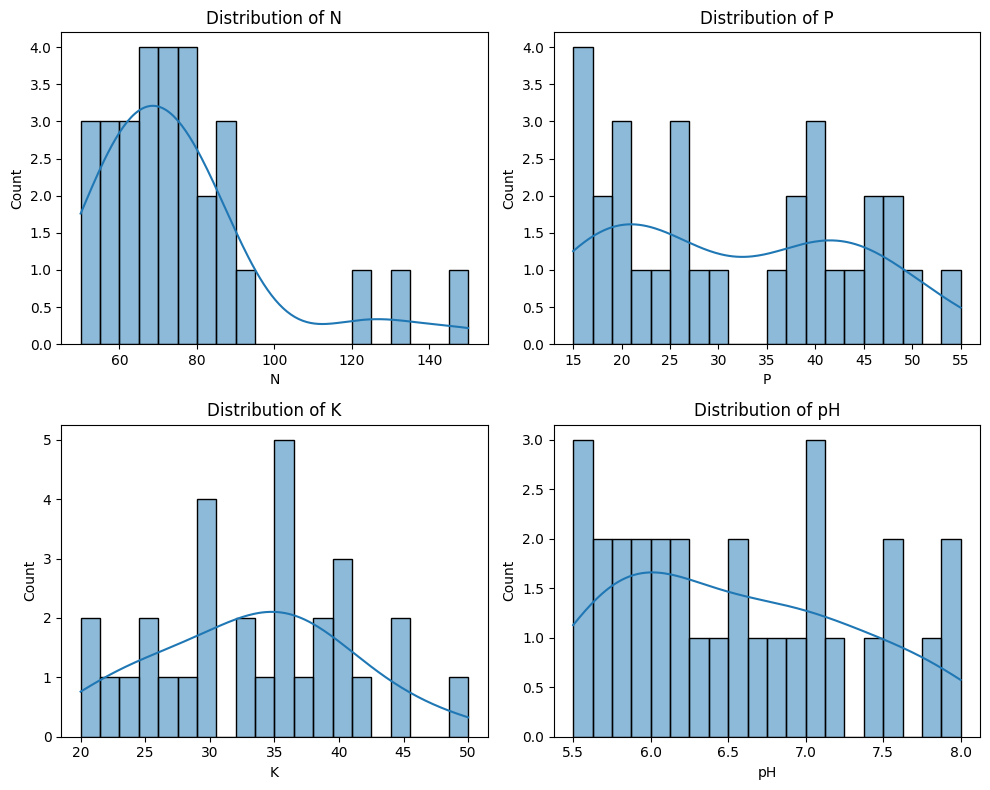

States with highest soil N:


,state,N
22,Punjab,150
8,Haryana,130
27,Uttar Pradesh,120
5,Delhi,90
21,Puducherry,88
29,West Bengal,85
3,Bihar,85
28,Uttarakhand,80
24,Tamil Nadu,80
0,Andhra Pradesh,78


In [4]:
# Soil feature distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), ["N", "P", "K", "pH"]):
    sns.histplot(soil[col].dropna(), bins=20, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

print("States with highest soil N:")
display(soil.sort_values("N", ascending=False).head(10)[["state", "N"]])

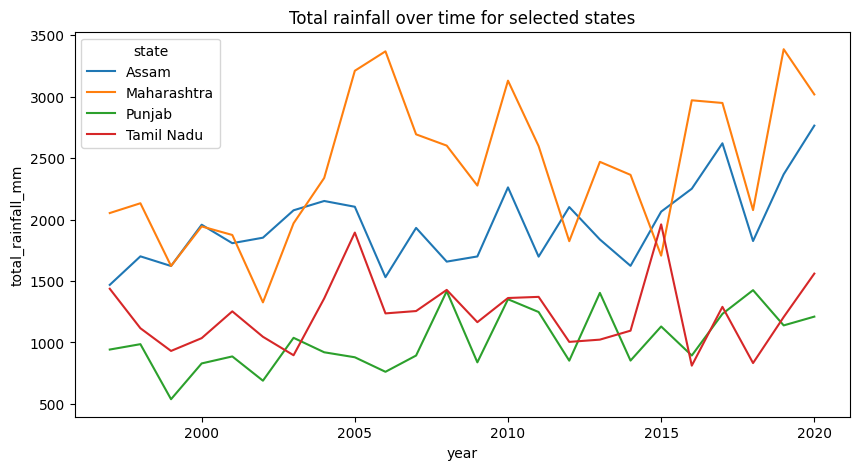

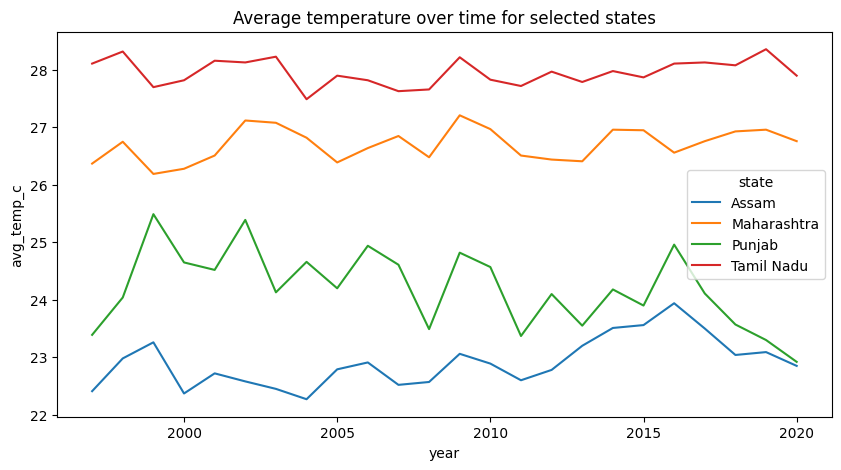

,state,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Andhra Pradesh,1997,28.21,1191.08,69.56
1,Andhra Pradesh,1998,28.21,1100.41,71.95
2,Andhra Pradesh,1999,28.03,603.67,66.91
3,Andhra Pradesh,2000,27.74,1070.25,70.73
4,Andhra Pradesh,2001,28.08,910.13,68.69


In [5]:
# Weather trends: rainfall and temperature over time (state-level averages)
state_year_weather = weather.groupby(["state", "year"], as_index=False).mean()

example_states = ["Punjab", "Maharashtra", "Tamil Nadu", "Assam"]
subset = state_year_weather[state_year_weather["state"].isin(example_states)]

plt.figure(figsize=(10, 5))
sns.lineplot(data=subset, x="year", y="total_rainfall_mm", hue="state")
plt.title("Total rainfall over time for selected states")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=subset, x="year", y="avg_temp_c", hue="state")
plt.title("Average temperature over time for selected states")
plt.show()

state_year_weather.head()

In [6]:
# Save cleaned/standardized versions
import os
os.makedirs("../data/processed", exist_ok=True)

soil_clean_path = "../data/processed/state_soil_data_clean.csv"
weather_clean_path = "../data/processed/state_weather_data_clean.csv"

soil.to_csv(soil_clean_path, index=False)
weather.to_csv(weather_clean_path, index=False)

print("Saved cleaned soil data to", soil_clean_path)
print("Saved cleaned weather data to", weather_clean_path)

Saved cleaned soil data to ../data/processed/state_soil_data_clean.csv
Saved cleaned weather data to ../data/processed/state_weather_data_clean.csv
